In [1]:
# Sample Data Source

# https://www.kaggle.com/code/abhashrai/customer-retention-analysis-prediction/notebook

In [2]:
# Import Libraries

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import builtins
from scipy.stats import zscore


'''
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

import pickle

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

'''

'\nfrom sklearn.model_selection import StratifiedKFold\nfrom sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report\n\nfrom sklearn.model_selection import train_test_split\n\nfrom sklearn.preprocessing import OneHotEncoder\n\nimport pickle\n\nfrom sklearn.decomposition import PCA\n\nfrom sklearn.linear_model import LogisticRegression\n\nfrom sklearn.naive_bayes import GaussianNB\nfrom sklearn.naive_bayes import MultinomialNB\n\nfrom sklearn.neighbors import KNeighborsClassifier\n\nfrom sklearn.tree import DecisionTreeClassifier\n\nfrom sklearn.ensemble import RandomForestClassifier\n\nimport xgboost as xgb\n\n'

In [3]:
# The dataset is not relly split in a balanced way. So, I'll import train and test data
# as a single data and split it later

df = pd.concat(
    [
        pd.read_csv('customer_churn_dataset-testing-master.csv'), 
        pd.read_csv('customer_churn_dataset-training-master.csv')
    ], 
    axis=0)
df.reset_index(drop=True, inplace=True)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.00,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.00,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.00,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.00,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.00,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
505203,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
505204,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
505205,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [4]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [5]:
df.describe(include=[object]) 

,Gender,Subscription Type,Contract Length
count,505206,505206,505206
unique,2,3,3
top,Male,Standard,Annual
freq,280273,170630,198608


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


In [7]:
# Initial Dataset Preprocessing
df.drop(columns='CustomerID', inplace=True) # removing unnecessary colum

df.columns = [col.lower().replace(' ', '_') for col in df.columns] # renaming the column names

In [8]:
df.shape

(505207, 11)

In [9]:
df.isnull().sum()

age                  1
gender               1
tenure               1
usage_frequency      1
support_calls        1
payment_delay        1
subscription_type    1
contract_length      1
total_spend          1
last_interaction     1
churn                1
dtype: int64

In [10]:
df[df.isna().any(axis=1)]

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
263669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.dropna(inplace=True) # Removing the single missing value row

In [12]:
df.shape

(505206, 11)

In [13]:
descrete_col = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']
for col in descrete_col:
    df[col] = df[col].astype(int)
df

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,22,Female,25,14,4,27,Basic,Monthly,598.00,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584.00,20,0
2,47,Male,27,10,2,29,Premium,Annual,757.00,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.00,18,0
4,53,Female,58,24,9,2,Standard,Annual,533.00,18,0
...,...,...,...,...,...,...,...,...,...,...,...
505202,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
505203,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
505204,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
505205,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


In [14]:
# Univarient Analysis

# Creating custom functions to visualize features

def make_histogram(df, target_feature, bins = 10, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    plt.hist(df[target_feature], bins=bins)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.ylabel('Count')
    plt.xlabel(target_feature)
    plt.title(f"Distribution of {target_feature.lower()}{additional}:\n")
    plt.grid()
    plt.show()
    print(f"Distribution of {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n{df[target_feature].skew():.3f} Skewness\n")

def make_piechart(df, target_feature, additional=''):
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    
    palette_color = sns.color_palette('bright')
    plt.pie(data, labels=keys, colors=palette_color, autopct='%.0f%%')
    plt.title(f"Distribution of Cutomer's {target_feature}:")
    plt.show()
    print_str = f"Distribution of cutomer's {target_feature.lower()}{additional}:"
    for k, v in zip(keys, data):
        print_str += f"\n{v} {k}"
    print(print_str)

def make_barplot(df, target_feature, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    plt.bar(keys, data)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.xlabel(f'{target_feature.capitalize()}{additional}')
    plt.ylabel('Frequency')
    plt.title(f"Distribution of cutomer's {target_feature.lower()}{additional}\n")
    plt.grid(axis='y')
    plt.show()
    print(f"Distribution of cutomer's {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n\n{df[target_feature].skew():.3f} Skewness\n")
    
def make_boxplot(df, feature):
    plt.figure(figsize=(10,5))
    sns.boxplot(df, x=feature)
    plt.title(f"Boxplot of {feature}\n")
    plt.xlabel(feature)
    plt.ylabel("Values")
    plt.show()

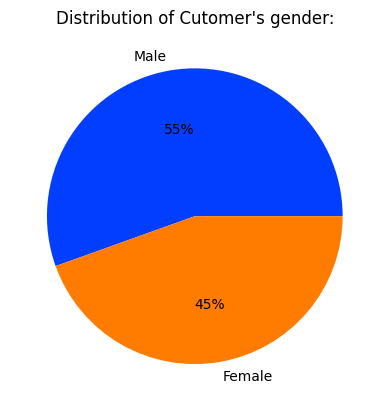

Distribution of cutomer's gender:
280273 Male
224933 Female


In [15]:
make_piechart(df, 'gender')

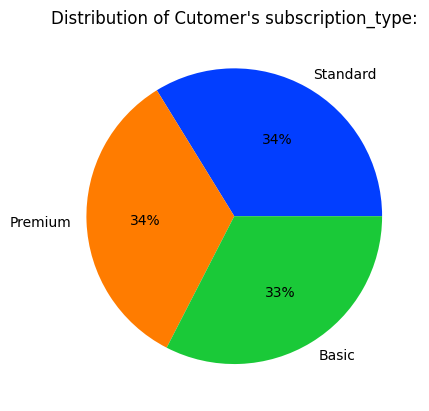

Distribution of cutomer's subscription_type:
170630 Standard
170099 Premium
164477 Basic


In [16]:
make_piechart(df, 'subscription_type')

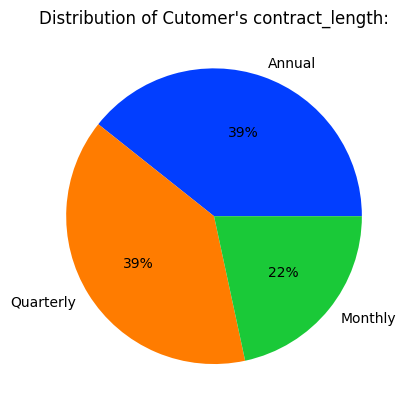

Distribution of cutomer's contract_length:
198608 Annual
197364 Quarterly
109234 Monthly


In [17]:
make_piechart(df, 'contract_length')

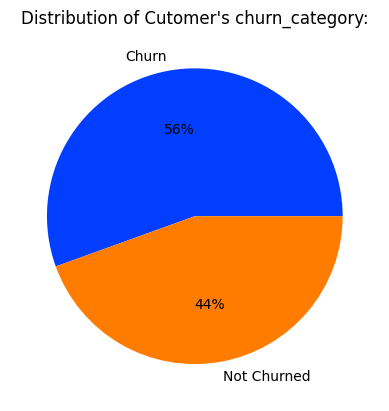

Distribution of cutomer's churn_category:
280492 Churn
224714 Not Churned


In [18]:
filtered = df.copy()
filtered['churn_category'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]
make_piechart(filtered, 'churn_category')

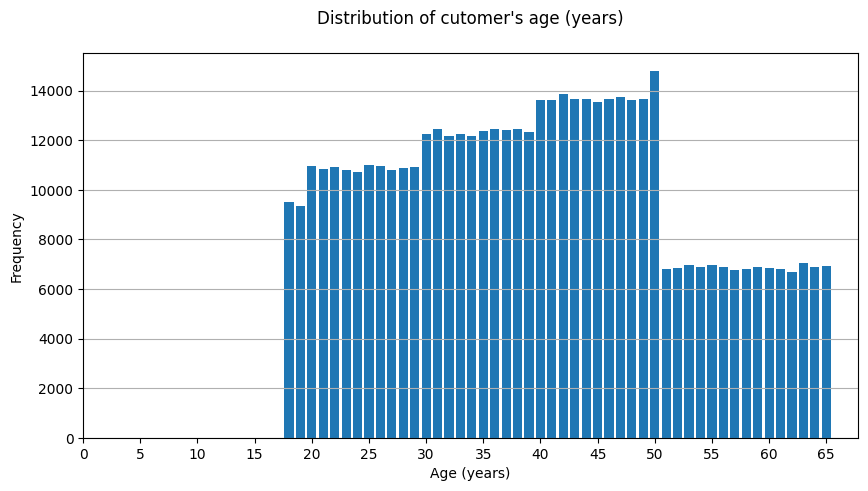

Distribution of cutomer's age (years): 39.70 ± 40.00 years
Median: 40.00 years
Minimum: 18 years
Maximum: 65 years

0.144 Skewness



In [19]:
make_barplot(df, 'age', custom_ticks=np.arange(0, 66, 5), additional=' (years)', unit='years')

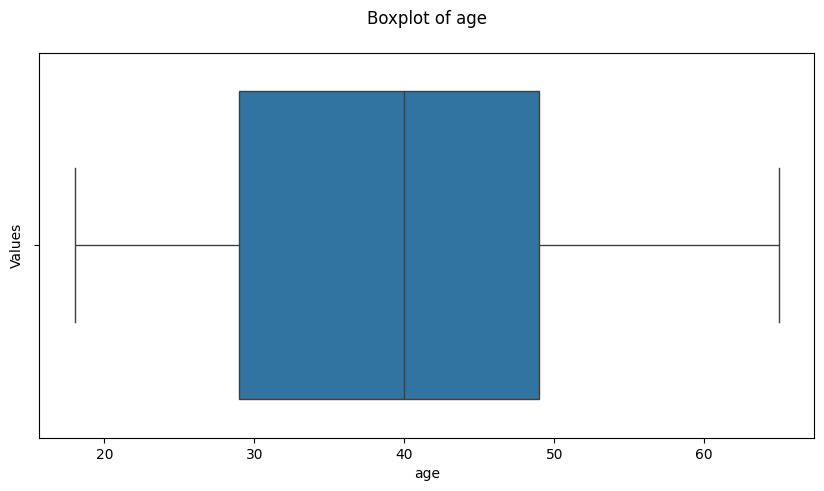

In [20]:
make_boxplot(df, 'age')

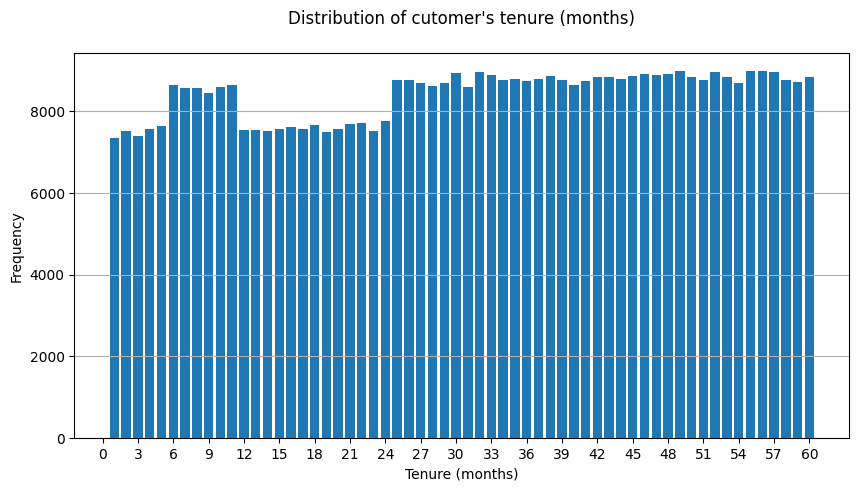

Distribution of cutomer's tenure (months): 31.35 ± 32.00 months
Median: 32.00 months
Minimum: 1 months
Maximum: 60 months

-0.070 Skewness



In [21]:
make_barplot(df, 'tenure', custom_ticks=np.arange(0, 61, 3), additional=' (months)', unit='months')

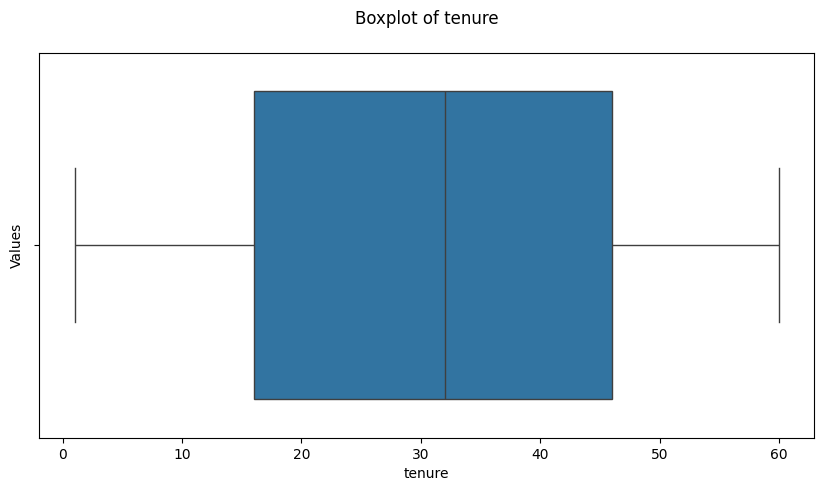

In [22]:
make_boxplot(df, 'tenure')

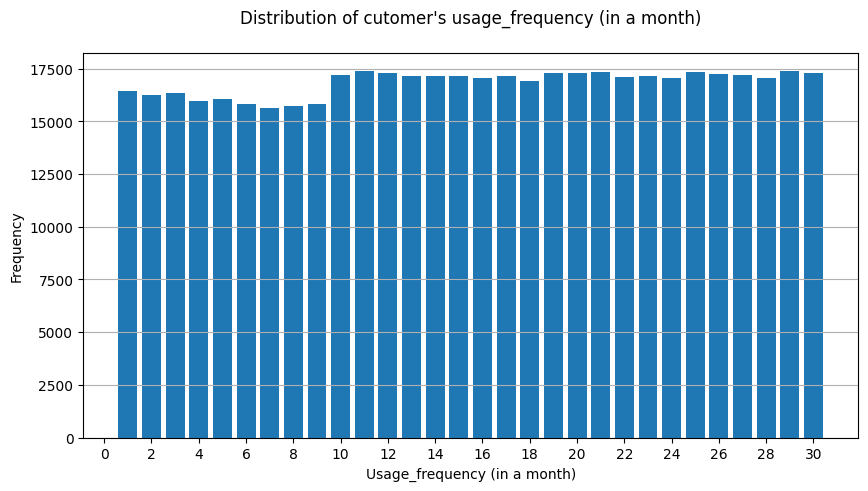

Distribution of cutomer's usage_frequency (in a month): 15.71 ± 16.00 times
Median: 16.00 times
Minimum: 1 times
Maximum: 30 times

-0.034 Skewness



In [23]:
make_barplot(df, 'usage_frequency', custom_ticks=np.arange(0, 31, 2), unit='times', additional=' (in a month)')


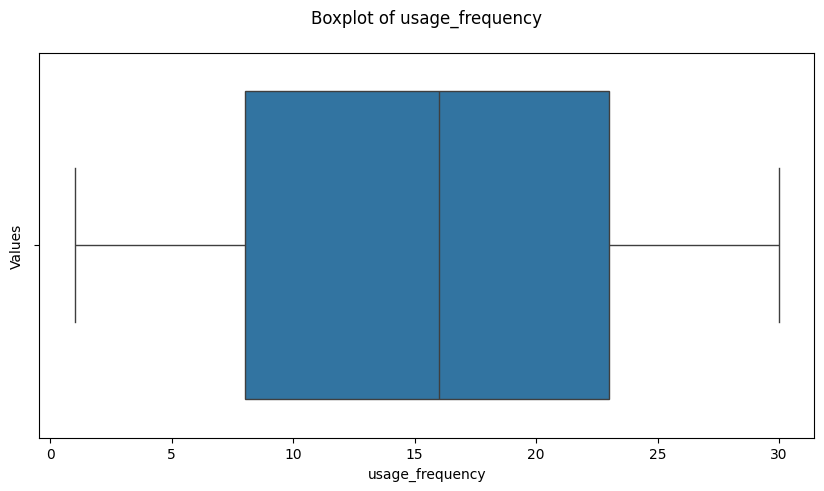

In [24]:
make_boxplot(df, 'usage_frequency')

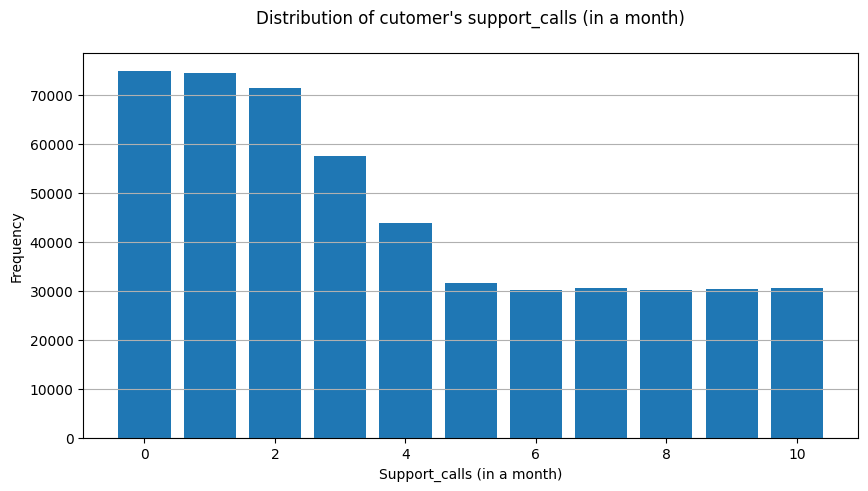

Distribution of cutomer's support_calls (in a month): 3.83 ± 3.00 calls
Median: 3.00 calls
Minimum: 0 calls
Maximum: 10 calls

0.544 Skewness



In [25]:
make_barplot(df, 'support_calls', unit='calls', additional=' (in a month)')

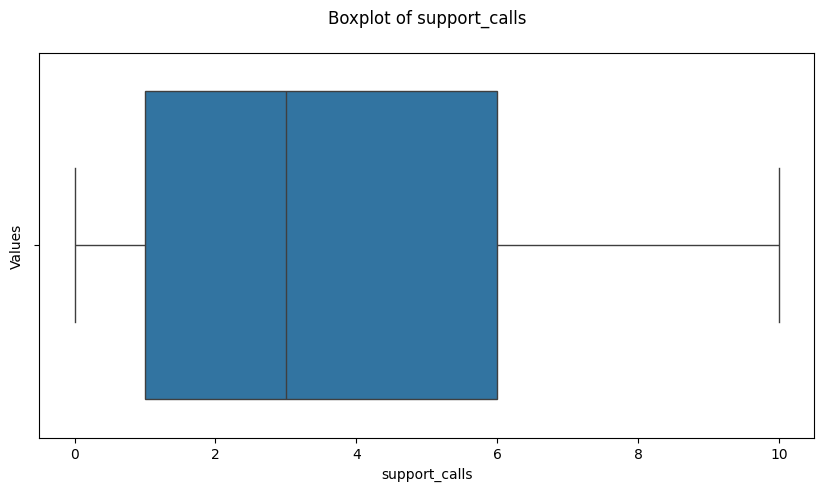

In [26]:
make_boxplot(df, 'support_calls')

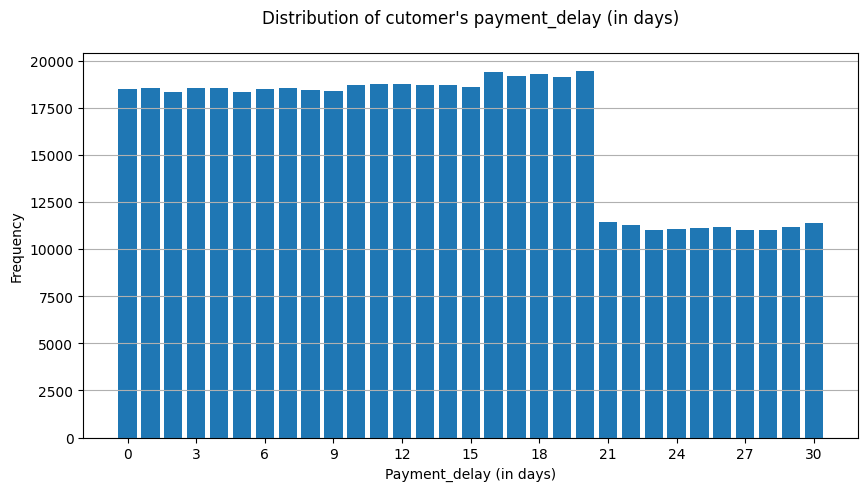

Distribution of cutomer's payment_delay (in days): 13.50 ± 13.00 days
Median: 13.00 days
Minimum: 0 days
Maximum: 30 days

0.200 Skewness



In [27]:
make_barplot(df, 'payment_delay', custom_ticks=np.arange(0, 32, 3), unit='days', additional=' (in days)')

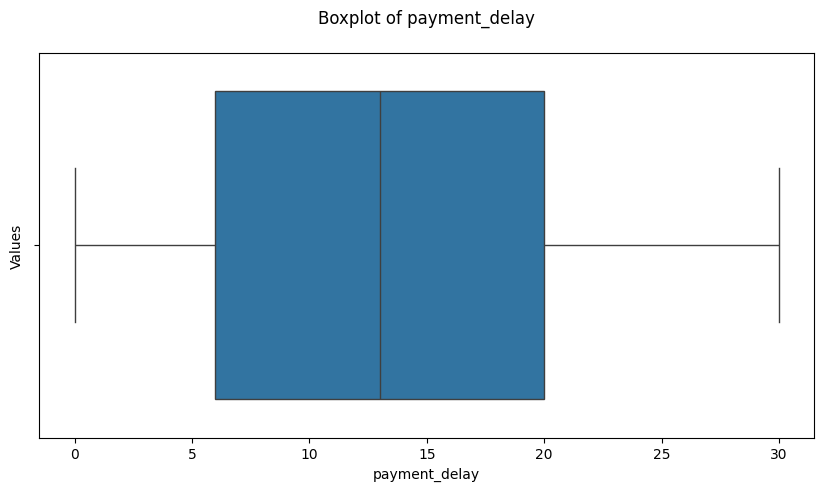

In [28]:
make_boxplot(df, 'payment_delay')

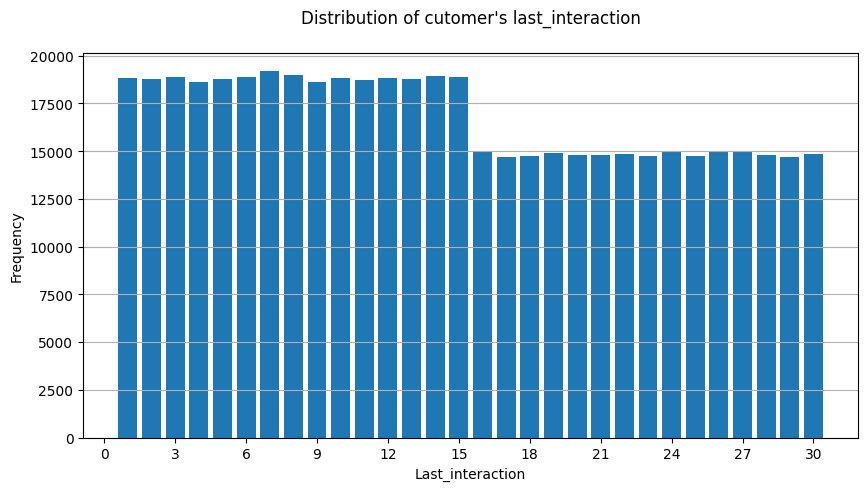

Distribution of cutomer's last_interaction: 14.61 ± 14.00 days
Median: 14.00 days
Minimum: 1 days
Maximum: 30 days

0.155 Skewness



In [29]:
make_barplot(df, 'last_interaction', custom_ticks=np.arange(0, 32, 3), unit='days', additional='')

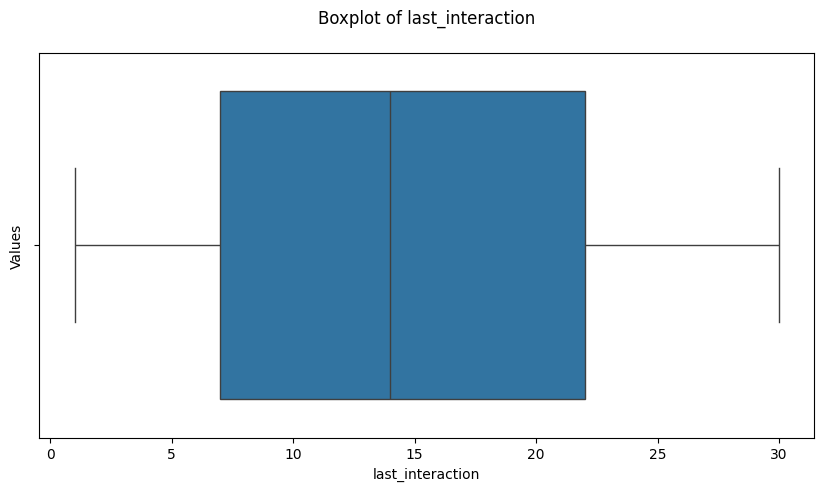

In [30]:
make_boxplot(df, 'last_interaction')

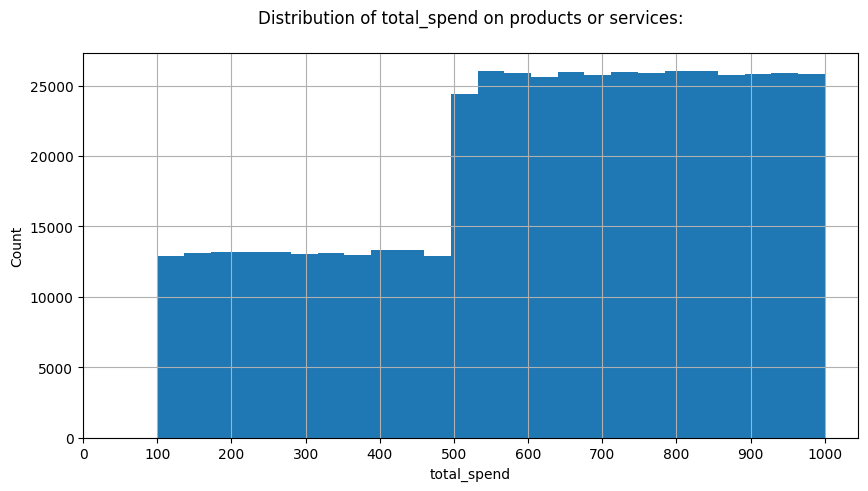

Distribution of total_spend on products or services: 620.07 ± 648.90 USD
Median: 648.90 USD
Minimum: 100.0 USD
Maximum: 1000.0 USD
-0.395 Skewness



In [31]:
make_histogram(df, 'total_spend', bins=25, custom_ticks=np.arange(0, 1001, 100), unit='USD', additional=" on products or services")


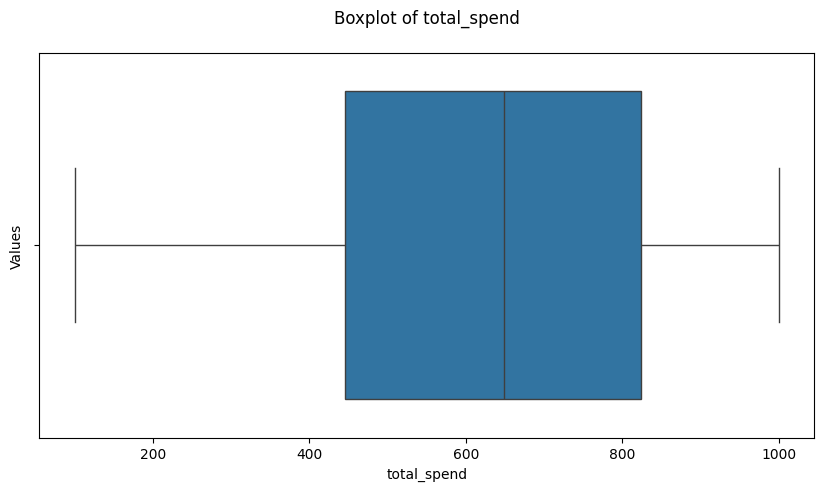

In [32]:
make_boxplot(df, 'total_spend')

In [33]:
# Multivariate Analysis

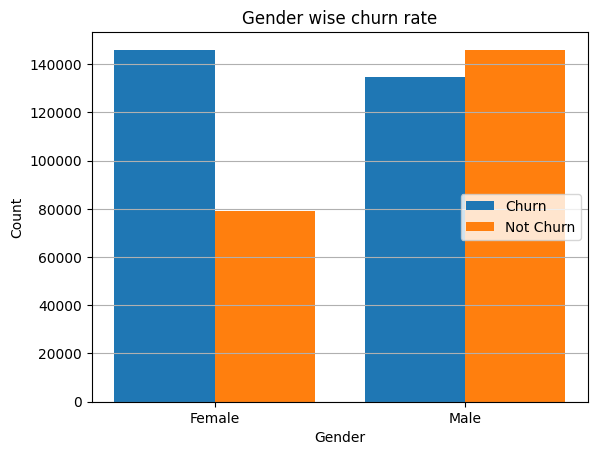

In [34]:
# Do gender and churn rate have any relationship?

gender_churn = df.groupby(['gender', 'churn']).size().unstack()

X = list(gender_churn.index)
churn_0 = list(gender_churn.iloc[:, 0])
churn_1 = list(gender_churn.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender wise churn rate")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

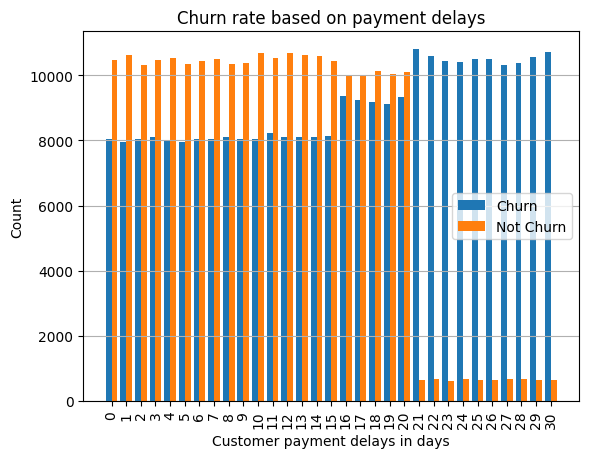

In [35]:
# Are there any noticeable trends in payment delays among customers who churned?

filtered = df.groupby(['payment_delay', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer payment delays in days")
plt.ylabel('Count')
plt.title("Churn rate based on payment delays")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

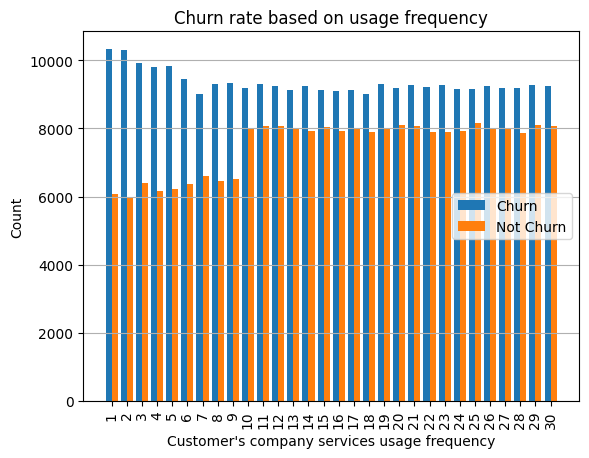

In [36]:
# What is the distribution of usage frequency for churned vs. non-churned customers?

filtered = df.groupby(['usage_frequency', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer's company services usage frequency")
plt.ylabel('Count')
plt.title("Churn rate based on usage frequency")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

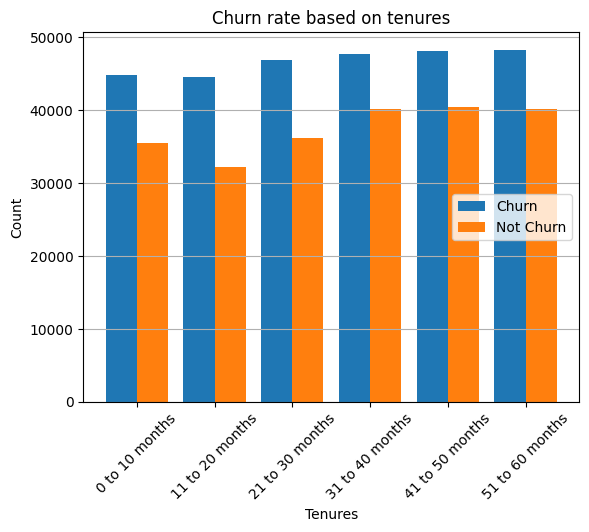

In [37]:
# Are customers with longer tenures less likely to churn?

def categorize_age(age):
    if 0 <= age <= 10:
        return '0 to 10 months'
    elif 11 <= age <= 20:
        return '11 to 20 months'
    elif 21 <= age <= 30:
        return '21 to 30 months'
    elif 31 <= age <= 40:
        return '31 to 40 months'
    elif 41 <= age <= 50:
        return '41 to 50 months'
    elif 51 <= age <= 60:
        return '51 to 60 months'
    else:
        pass # For nan values

filtered = df.copy()
filtered['tenure_segmentation'] = df['tenure'].apply(categorize_age)
filtered = filtered.groupby(['tenure_segmentation', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Tenures')
plt.ylabel('Count')
plt.title("Churn rate based on tenures")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

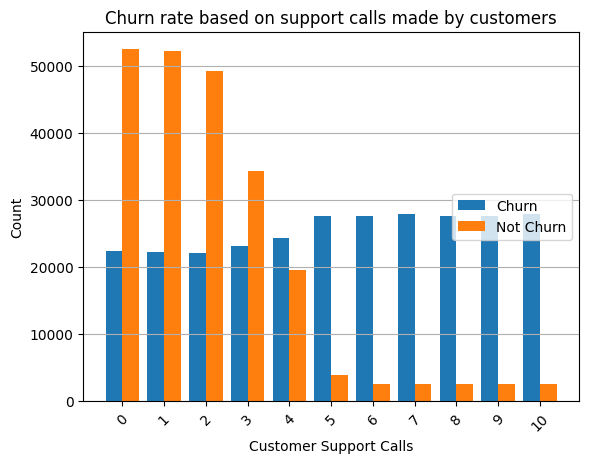

In [38]:
# Do customers with more support calls tend to churn more?

filtered = df.groupby(['support_calls', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Customer Support Calls')
plt.ylabel('Count')
plt.title("Churn rate based on support calls made by customers")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

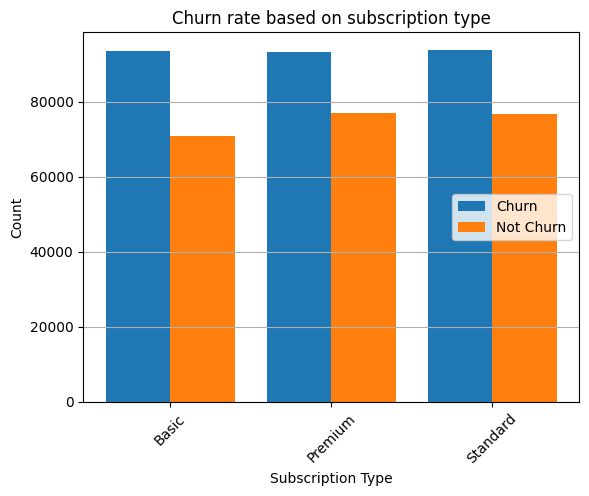

In [39]:
# Does the subscription type influence the churn rate?

filtered = df.groupby(['subscription_type', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.title("Churn rate based on subscription type")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

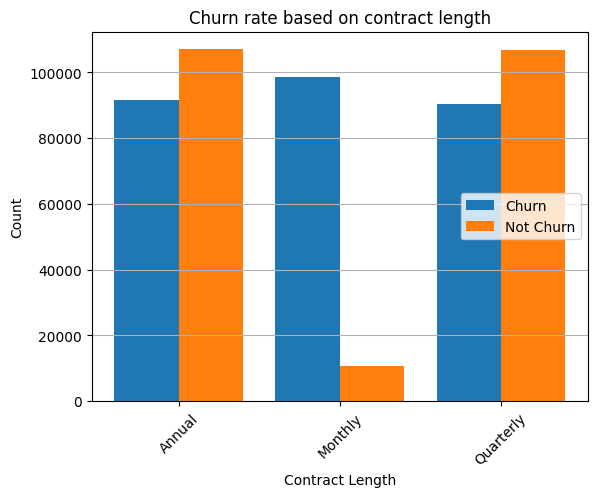

In [40]:
# Is there a pattern in contract length for customers who churned?

filtered = df.groupby(['contract_length', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Contract Length')
plt.ylabel('Count')
plt.title("Churn rate based on contract length")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

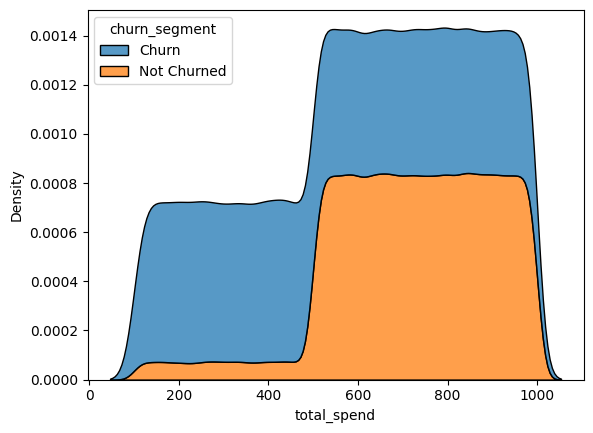

In [41]:
# Is there a correlation between total spend and churn rate?

filtered = df.copy()
filtered['churn_segment'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]

sns.kdeplot(data=filtered, x="total_spend", hue="churn_segment", multiple="stack")
plt.show()

In [42]:
# Correlation

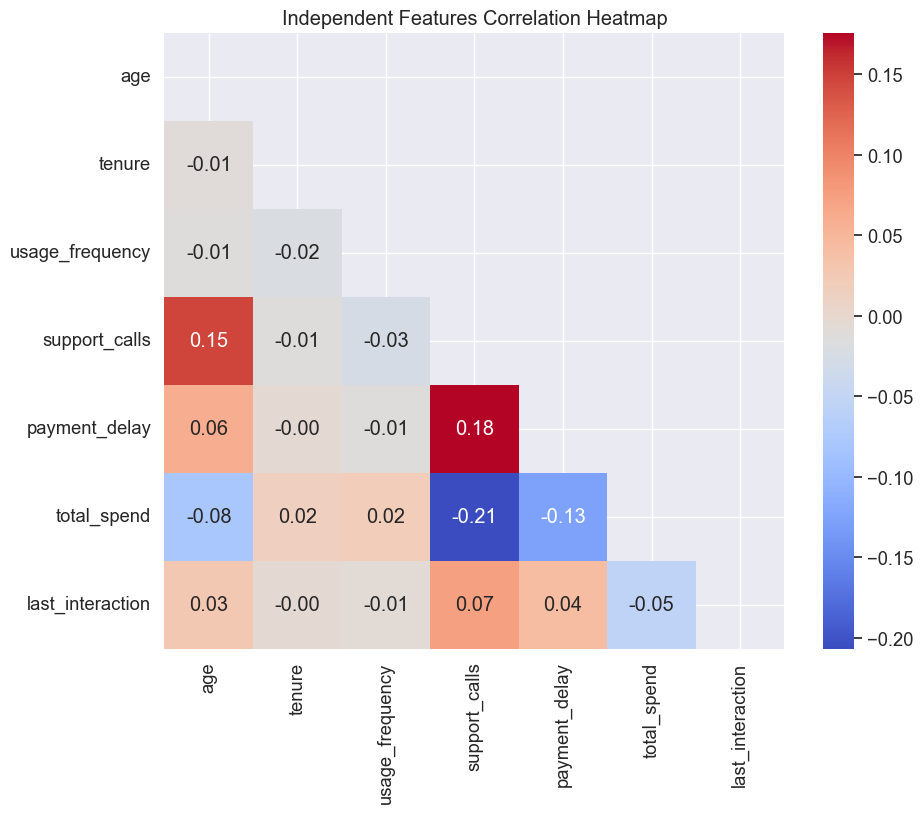

In [43]:
# Independent Features Correlation

independent_features_df = df.select_dtypes(include=['number']).copy().drop(columns=['churn'])

corr_matrix = independent_features_df.corr()

# Creating a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
plt.title("Independent Features Correlation Heatmap")
plt.show()


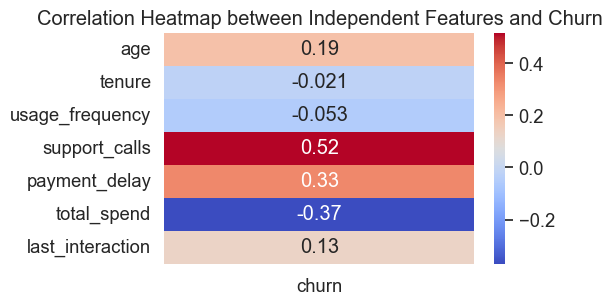

In [44]:
# Inpedendent features correlation with prediction labels

correlation_data = df.select_dtypes(include=['number']).corr().loc[:'last_interaction', 'churn']


# Create a heatmap
plt.figure(figsize=(5, 3))
sns.set(font_scale=1.2)
sns.heatmap(correlation_data.to_frame(), annot=True, cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap between Independent Features and Churn")
plt.show()

In [45]:
# Duplicates

df[df.duplicated()]


,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn


In [46]:
# Null values

'''
Missing values were dropped pre EDA because there was just a single row of missing values which before performing analysis won't affect result of analysis.
'''

"\nMissing values were dropped pre EDA because there was just a single row of missing values which before performing analysis won't affect result of analysis.\n"

In [47]:
# Add in additional data fields and create correlations

'''
Industry
Role
Market Segment (SMB, Mid, Ent, etc.)
Days_Since....
    Days_Since_Email_Opened
    Days_Since_CTA_Clicked
    Days_Since_Website_Visited
    Days_Since_Event_Attended
    Days_Since_Last_Login
Number_Of_Logins

'''

'\nIndustry\nRole\nMarket Segment (SMB, Mid, Ent, etc.)\nDays_Since....\n    Days_Since_Email_Opened\n    Days_Since_CTA_Clicked\n    Days_Since_Website_Visited\n    Days_Since_Event_Attended\n    Days_Since_Last_Login\nNumber_Of_Logins\n\n'

In [48]:
# Industry - 50% Tech, 15% Finance, no correlation

# Record Count of df
n = len(df)

# Define the industry categories
industry_categories = [
    "Technology", "Finance", "Healthcare", "Energy", "Consumer Goods",
    "Retail", "Transportation", "Media & Entertainment", "Real Estate",
    "Telecommunications", "Education", "Government & Public", "Manufacturing",
    "Agriculture", "Construction", "Hospitality", "Legal", "Nonprofit", "Professional Services"
]

# Remove Technology and Finance from random pool
other_industries = [i for i in industry_categories if i not in ("Technology", "Finance")]

# Compute counts
n_tech = int(n * 0.50)
n_finance = int(n * 0.15)
n_other = n - n_tech - n_finance

# Sample other industries
other_industry_samples = np.random.choice(other_industries, size=n_other, replace=True)

# Combine all samples
industries = (
    ["Technology"] * n_tech +
    ["Finance"] * n_finance +
    list(other_industry_samples)
)

# Shuffle the list
np.random.shuffle(industries)

# Add to the DataFrame
df["Industry"] = industries

# Print percentage distribution
print("\nIndustry Distribution (Percentages):")
print(df["Industry"].value_counts(normalize=True) * 100)



Industry Distribution (Percentages):
Industry
Technology               50.000000
Finance                  14.999822
Construction              2.089643
Manufacturing             2.086080
Media & Entertainment     2.078558
Retail                    2.074599
Legal                     2.072422
Transportation            2.069849
Healthcare                2.067869
Government & Public       2.062525
Telecommunications        2.058962
Professional Services     2.058170
Education                 2.058170
Consumer Goods            2.057774
Real Estate               2.046690
Agriculture               2.038574
Energy                    2.037387
Nonprofit                 2.026698
Hospitality               2.016207
Name: proportion, dtype: float64


In [49]:
# Role - Random Distribution, No Correlation

# Sample list of 20 SaaS buyer roles
Roles = [
    "Chief Technology Officer (CTO)",
    "Chief Product Officer (CPO)",
    "VP of Sales",
    "Director of IT",
    "Head of Growth",
    "Product Manager",
    "Technical Product Manager",
    "Software Engineer",
    "DevOps Engineer",
    "Engineering Manager",
    "Growth Marketing Manager",
    "Marketing Operations Manager",
    "Sales Operations Analyst",
    "Account Executive",
    "Business Development Manager",
    "Data Analyst",
    "IT Manager",
    "Procurement Manager",
    "Customer Success Manager",
    "Implementation Specialist"
]

# Assuming df already exists
# Randomly assign a role to each row
df["Role"] = np.random.choice(Roles, size=len(df), replace=True)

# Print percentage distribution
print("\nRole Distribution (Percentages):")
print(df["Role"].value_counts(normalize=True) * 100)



Role Distribution (Percentages):
Role
Sales Operations Analyst          5.109005
Engineering Manager               5.041706
Technical Product Manager         5.025475
Data Analyst                      5.022506
Procurement Manager               5.018745
Chief Product Officer (CPO)       5.018745
VP of Sales                       5.016567
Customer Success Manager          5.015380
Head of Growth                    5.013203
IT Manager                        5.006868
Business Development Manager      5.000534
Director of IT                    4.997763
Implementation Specialist         4.988658
Growth Marketing Manager          4.987866
Account Executive                 4.983314
Software Engineer                 4.970646
Chief Technology Officer (CTO)    4.955008
Product Manager                   4.952633
Marketing Operations Manager      4.951248
DevOps Engineer                   4.924130
Name: proportion, dtype: float64


In [50]:
# Market Segment (SMB, Mid, Ent, etc.) - Assigned Distribution, No Correlation

'''
 "Small Business" = 15%
 "Mid-Market" = 8%
 "Enterprise" = 55%
 "Government" = 3%
 "Education" = 11%
 "Nonprofit" = 8%
'''

# Check length of df
n = len(df)

# Define segments and their target distribution
segment_distribution = {
    "Small Business": 0.15,
    "Mid-Market": 0.08,
    "Enterprise": 0.55,
    "Government": 0.03,
    "Education": 0.11,
    "Nonprofit": 0.08
}

# Compute how many of each segment to assign
segment_counts = {segment: int(n * pct) for segment, pct in segment_distribution.items()}

#print(type(segment_counts))
assigned = builtins.sum(segment_counts.values())
if assigned < n:
    # Fill in remaining with the largest segment ("Enterprise" here)
    segment_counts["Enterprise"] += n - assigned

# Build list of segments
segments = []
for segment, count in segment_counts.items():
    segments.extend([segment] * count)

# Shuffle to randomize order
np.random.shuffle(segments)

# Add to DataFrame
df["Market_Segment"] = segments

# Print percentage distribution
print("\nMarket Segment Distribution (Percentages):")
print(df["Market_Segment"].value_counts(normalize=True) * 100)


Market Segment Distribution (Percentages):
Market_Segment
Enterprise        55.000534
Small Business    14.999822
Education         10.999869
Nonprofit          7.999905
Mid-Market         7.999905
Government         2.999964
Name: proportion, dtype: float64


In [51]:
# Days_Since_Email_Opened - Poisson Distribution, 0 - 35, .15 Correlation with 'churn'

# Ensure reproducibility
np.random.seed(42)

# Ensure 'churn' is present
assert 'churn' in df.columns, "df must have a 'churn' column"
n = len(df)

target_corr = 0.15
tolerance = 0.015
best_diff = float('inf')
best_scaled_days = None
best_corr = None
best_blend = None

# Step 1: Generate base Poisson values and clip to range
mean_days = 3  # low mean for clustering near 0
base_days = np.random.poisson(lam=mean_days, size=n)
base_days = np.clip(base_days, 0, 35)

# Step 2: Normalize churn
if df['churn'].nunique() <= 2:
    churn_numeric = df['churn'].astype(float)
else:
    churn_numeric = zscore(df['churn'])

print("Starting refined blend factor search...")
for blend_factor in np.arange(0.18, 0.40, 0.001):
    blended = (1 - blend_factor) * zscore(base_days) + blend_factor * churn_numeric
    scaled = np.round((blended - blended.min()) / (blended.max() - blended.min()) * 35)
    scaled = scaled.clip(0, 35).astype(int)

    # NO inversion here — keep original scale

    corr = np.corrcoef(scaled, churn_numeric)[0, 1]

    diff = abs(corr - target_corr)
    if diff < best_diff:
        best_diff = diff
        best_scaled_days = scaled
        best_corr = corr
        best_blend = blend_factor
        print(f"Blend factor: {blend_factor:.3f} → Correlation: {corr:.3f} (diff {diff:.3f})")
        if diff <= tolerance:
            break

# Step 4: Assign best found to DataFrame
df["Days_Since_Email_Opened"] = best_scaled_days

# Step 5: Print final results
print(f"✅ Best blend factor: {best_blend:.3f} → Correlation: {best_corr:.3f}")

Starting refined blend factor search...
Blend factor: 0.180 → Correlation: 0.116 (diff 0.034)
Blend factor: 0.205 → Correlation: 0.135 (diff 0.015)
✅ Best blend factor: 0.205 → Correlation: 0.135


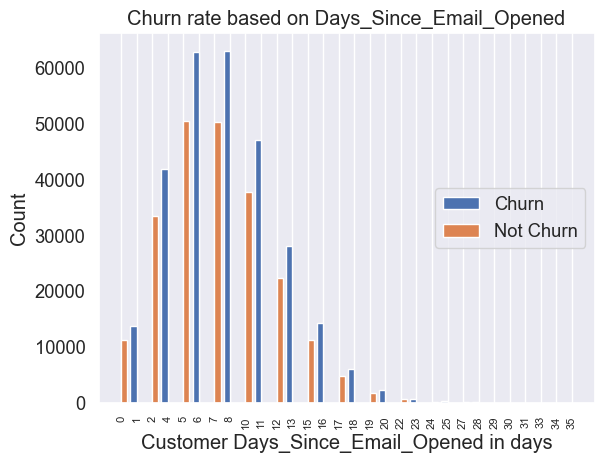

In [52]:
# Are there any noticeable trends in Days_Since_Email_Opened among customers who churned?

filtered = df.groupby(['Days_Since_Email_Opened', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label='Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label='Not Churn')

plt.xticks(X_axis, X, rotation=90, fontsize=8)  # Set smaller font size here
plt.xlabel("Customer Days_Since_Email_Opened in days")
plt.ylabel('Count')
plt.title("Churn rate based on Days_Since_Email_Opened")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

In [53]:
# Days_Since_CTA_Clicked - Poisson Distribution, 0 - 40, .07 Correlation with 'churn'

# Ensure reproducibility
np.random.seed(42)

# Ensure 'churn' is present
assert 'churn' in df.columns, "df must have a 'churn' column"
n = len(df)

target_corr = 0.07
tolerance = 0.015
best_diff = float('inf')
best_scaled_days = None
best_corr = None
best_blend = None

# Step 1: Generate base Poisson values and clip to range
mean_days = 7  # low mean for clustering near 0
base_days = np.random.poisson(lam=mean_days, size=n)
base_days = np.clip(base_days, 0, 40)

# Step 2: Normalize churn
if df['churn'].nunique() <= 2:
    churn_numeric = df['churn'].astype(float)
else:
    churn_numeric = zscore(df['churn'])

print("Starting refined blend factor search for Days_Since_CTA_Clicked...")
for blend_factor in np.arange(0.18, 0.40, 0.001):
    blended = (1 - blend_factor) * zscore(base_days) + blend_factor * churn_numeric
    scaled = np.round((blended - blended.min()) / (blended.max() - blended.min()) * 40)
    scaled = scaled.clip(0, 40).astype(int)

    corr = np.corrcoef(scaled, churn_numeric)[0, 1]

    diff = abs(corr - target_corr)
    if diff < best_diff:
        best_diff = diff
        best_scaled_days = scaled
        best_corr = corr
        best_blend = blend_factor
        print(f"Blend factor: {blend_factor:.3f} → Correlation: {corr:.3f} (diff {diff:.3f})")
        if diff <= tolerance:
            break

# Step 4: Assign best found to DataFrame
df["Days_Since_CTA_Clicked"] = best_scaled_days

# Step 5: Print final results
print(f"✅ Best blend factor: {best_blend:.3f} → Correlation: {best_corr:.3f}")

   

Starting refined blend factor search for Days_Since_CTA_Clicked...
Blend factor: 0.180 → Correlation: 0.112 (diff 0.042)
✅ Best blend factor: 0.180 → Correlation: 0.112


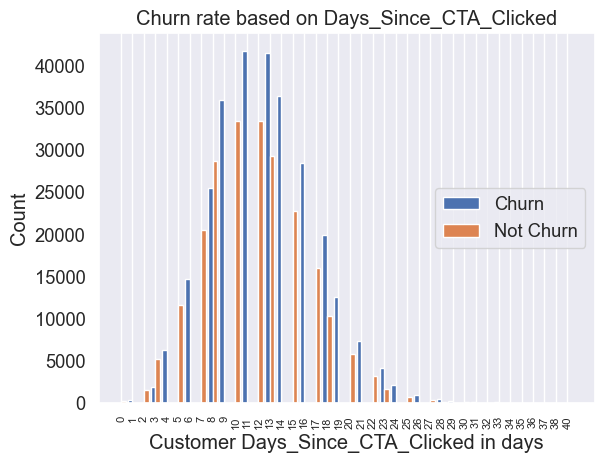

In [54]:
# Are there any noticeable trends in Days_Since_CTA_Clicked among customers who churned?

filtered = df.groupby(['Days_Since_CTA_Clicked', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label='Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label='Not Churn')

plt.xticks(X_axis, X, rotation=90, fontsize=8)  # Smaller font size
plt.xlabel("Customer Days_Since_CTA_Clicked in days")
plt.ylabel('Count')
plt.title("Churn rate based on Days_Since_CTA_Clicked")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


In [55]:
# Days_Since_Website_Visited - Poisson Distribution, 0 - 32, .07 Correlation with 'churn'

# Ensure reproducibility
np.random.seed(42)

# Ensure 'churn' is present
assert 'churn' in df.columns, "df must have a 'churn' column"
n = len(df)

target_corr = 0.07
tolerance = 0.015
best_diff = float('inf')
best_scaled_days = None
best_corr = None
best_blend = None

# Step 1: Generate base Poisson values and clip to range
mean_days = 7  # slightly higher mean than other behaviors
base_days = np.random.poisson(lam=mean_days, size=n)
base_days = np.clip(base_days, 0, 32)

# Step 2: Normalize churn
if df['churn'].nunique() <= 2:
    churn_numeric = df['churn'].astype(float)
else:
    churn_numeric = zscore(df['churn'])

print("Starting refined blend factor search for Days_Since_Website_Visited...")
for blend_factor in np.arange(0.18, 0.40, 0.001):
    blended = (1 - blend_factor) * zscore(base_days) + blend_factor * churn_numeric
    scaled = np.round((blended - blended.min()) / (blended.max() - blended.min()) * 32)
    scaled = scaled.clip(0, 32).astype(int)

    corr = np.corrcoef(scaled, churn_numeric)[0, 1]

    diff = abs(corr - target_corr)
    if diff < best_diff:
        best_diff = diff
        best_scaled_days = scaled
        best_corr = corr
        best_blend = blend_factor
        print(f"Blend factor: {blend_factor:.3f} → Correlation: {corr:.3f} (diff {diff:.3f})")
        if diff <= tolerance:
            break

# Step 4: Assign best found to DataFrame
df["Days_Since_Website_Visited"] = best_scaled_days

# Step 5: Print final results
print(f"✅ Best blend factor: {best_blend:.3f} → Correlation: {best_corr:.3f}")   


Starting refined blend factor search for Days_Since_Website_Visited...
Blend factor: 0.180 → Correlation: 0.094 (diff 0.024)
✅ Best blend factor: 0.180 → Correlation: 0.094


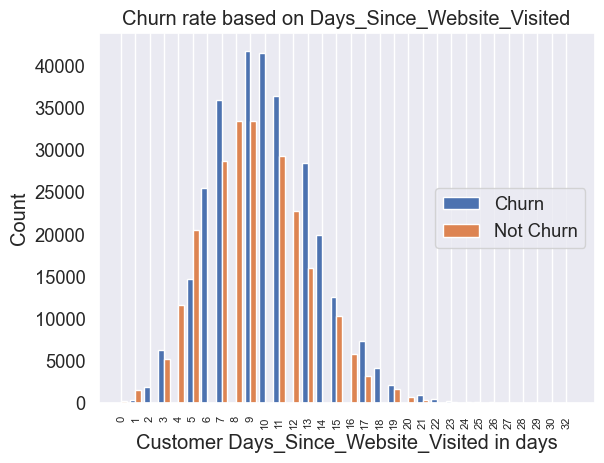

In [56]:
# Are there any noticeable trends in Days_Since_Website_Visited among customers who churned?

filtered = df.groupby(['Days_Since_Website_Visited', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label='Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label='Not Churn')

plt.xticks(X_axis, X, rotation=90, fontsize=8)  # Smaller font size
plt.xlabel("Customer Days_Since_Website_Visited in days")
plt.ylabel('Count')
plt.title("Churn rate based on Days_Since_Website_Visited")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


In [57]:
# Days_Since_Event_Attended - Poisson Distribution, 0 - 55, .03 Correlation with 'churn'

# Ensure reproducibility
np.random.seed(42)

# Ensure 'churn' is present
assert 'churn' in df.columns, "df must have a 'churn' column"
n = len(df)

target_corr = 0.03
tolerance = 0.015
best_diff = float('inf')
best_scaled_days = None
best_corr = None
best_blend = None

# Step 1: Generate base Poisson values and clip to range
mean_days = 9  # Slightly higher mean to allow broader spread
base_days = np.random.poisson(lam=mean_days, size=n)
base_days = np.clip(base_days, 0, 55)

# Step 2: Normalize churn
if df['churn'].nunique() <= 2:
    churn_numeric = df['churn'].astype(float)
else:
    churn_numeric = zscore(df['churn'])

print("Starting refined blend factor search for Days_Since_Event_Attended...")
for blend_factor in np.arange(0.18, 0.40, 0.001):
    blended = (1 - blend_factor) * zscore(base_days) + blend_factor * churn_numeric
    scaled = np.round((blended - blended.min()) / (blended.max() - blended.min()) * 55)
    scaled = scaled.clip(0, 55).astype(int)

    corr = np.corrcoef(scaled, churn_numeric)[0, 1]

    diff = abs(corr - target_corr)
    if diff < best_diff:
        best_diff = diff
        best_scaled_days = scaled
        best_corr = corr
        best_blend = blend_factor
        print(f"Blend factor: {blend_factor:.3f} → Correlation: {corr:.3f} (diff {diff:.3f})")
        if diff <= tolerance:
            break

# Step 4: Assign best found to DataFrame
df["Days_Since_Event_Attended"] = best_scaled_days

# Step 5: Print final results
print(f"✅ Best blend factor: {best_blend:.3f} → Correlation: {best_corr:.3f}")

Starting refined blend factor search for Days_Since_Event_Attended...
Blend factor: 0.180 → Correlation: 0.106 (diff 0.076)
✅ Best blend factor: 0.180 → Correlation: 0.106


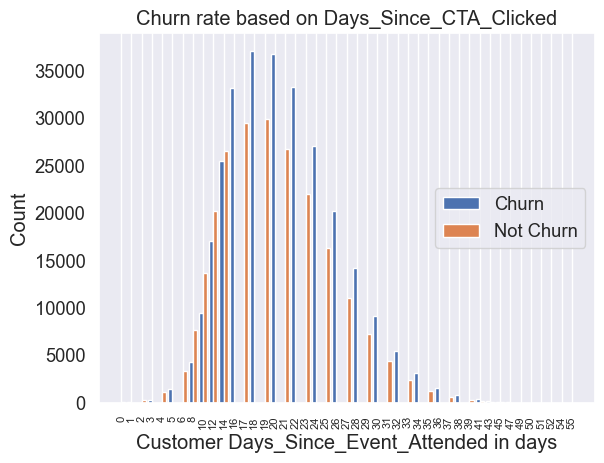

In [58]:
# Are there any noticeable trends in Days_Since_Event_Attended among customers who churned?

filtered = df.groupby(['Days_Since_Event_Attended', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label='Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label='Not Churn')

plt.xticks(X_axis, X, rotation=90, fontsize=8)  # Smaller font size
plt.xlabel("Customer Days_Since_Event_Attended in days")
plt.ylabel('Count')
plt.title("Churn rate based on Days_Since_CTA_Clicked")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


In [59]:
# Days_Since_Last_Login - Poisson Distribution, 0 - 102, 0.22 Correlation with 'churn'

# Ensure reproducibility
np.random.seed(42)

# Ensure 'churn' is present
assert 'churn' in df.columns, "df must have a 'churn' column"
n = len(df)

target_corr = 0.22
tolerance = 0.015
best_diff = float('inf')
best_scaled_days = None
best_corr = None
best_blend = None

# Step 1: Generate base Poisson values and clip to range
mean_days = 12  # Higher mean to spread across wider range
base_days = np.random.poisson(lam=mean_days, size=n)
base_days = np.clip(base_days, 0, 102)

# Step 2: Normalize churn
if df['churn'].nunique() <= 2:
    churn_numeric = df['churn'].astype(float)
else:
    churn_numeric = zscore(df['churn'])

print("Starting refined blend factor search for Days_Since_Last_Login...")
for blend_factor in np.arange(0.18, 0.40, 0.001):
    blended = (1 - blend_factor) * zscore(base_days) + blend_factor * churn_numeric
    scaled = np.round((blended - blended.min()) / (blended.max() - blended.min()) * 102)
    scaled = scaled.clip(0, 102).astype(int)

    corr = np.corrcoef(scaled, churn_numeric)[0, 1]

    diff = abs(corr - target_corr)
    if diff < best_diff:
        best_diff = diff
        best_scaled_days = scaled
        best_corr = corr
        best_blend = blend_factor
        print(f"Blend factor: {blend_factor:.3f} → Correlation: {corr:.3f} (diff {diff:.3f})")
        if diff <= tolerance:
            break

# Step 4: Assign best found to DataFrame
df["Days_Since_Last_Login"] = best_scaled_days

# Step 5: Print final results
print(f"✅ Best blend factor: {best_blend:.3f} → Correlation: {best_corr:.3f}")

Starting refined blend factor search for Days_Since_Last_Login...
Blend factor: 0.180 → Correlation: 0.107 (diff 0.113)
Blend factor: 0.182 → Correlation: 0.109 (diff 0.111)
Blend factor: 0.184 → Correlation: 0.113 (diff 0.107)
Blend factor: 0.186 → Correlation: 0.113 (diff 0.107)
Blend factor: 0.188 → Correlation: 0.113 (diff 0.107)
Blend factor: 0.190 → Correlation: 0.113 (diff 0.107)
Blend factor: 0.192 → Correlation: 0.118 (diff 0.102)
Blend factor: 0.194 → Correlation: 0.119 (diff 0.101)
Blend factor: 0.195 → Correlation: 0.119 (diff 0.101)
Blend factor: 0.197 → Correlation: 0.119 (diff 0.101)
Blend factor: 0.199 → Correlation: 0.122 (diff 0.098)
Blend factor: 0.201 → Correlation: 0.125 (diff 0.095)
Blend factor: 0.203 → Correlation: 0.125 (diff 0.095)
Blend factor: 0.204 → Correlation: 0.125 (diff 0.095)
Blend factor: 0.206 → Correlation: 0.126 (diff 0.094)
Blend factor: 0.208 → Correlation: 0.131 (diff 0.089)
Blend factor: 0.210 → Correlation: 0.132 (diff 0.088)
Blend factor: 0.

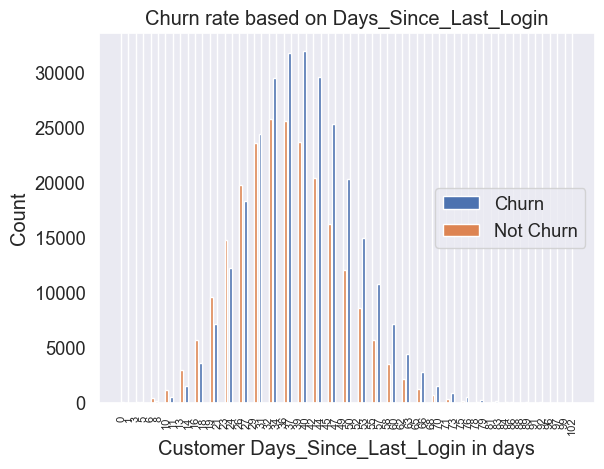

In [60]:
# Are there any noticeable trends in Days_Since_Last_Login among customers who churned?

filtered = df.groupby(['Days_Since_Last_Login', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label='Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label='Not Churn')

plt.xticks(X_axis, X, rotation=90, fontsize=8)  # Smaller font size
plt.xlabel("Customer Days_Since_Last_Login in days")
plt.ylabel('Count')
plt.title("Churn rate based on Days_Since_Last_Login")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


In [61]:
# Number_Of_Logins - Poisson Distribution, 0 - 22, -0.12 Correlation with 'churn'

# Ensure reproducibility
np.random.seed(42)

# Ensure 'churn' is present
assert 'churn' in df.columns, "df must have a 'churn' column"
n = len(df)

target_corr = -0.12
tolerance = 0.015
best_diff = float('inf')
best_scaled_values = None
best_corr = None
best_blend = None

# Step 1: Generate base Poisson values and clip to range
mean_logins = 8  # Mid-range mean to spread across 0–22
base_values = np.random.poisson(lam=mean_logins, size=n)
base_values = np.clip(base_values, 0, 22)

# Step 2: Normalize churn
if df['churn'].nunique() <= 2:
    churn_numeric = df['churn'].astype(float)
else:
    churn_numeric = zscore(df['churn'])

print("Starting refined blend factor search for Number_Of_Logins...")
for blend_factor in np.arange(0.18, 0.40, 0.001):
    blended = (1 - blend_factor) * zscore(base_values) - blend_factor * churn_numeric  # Note the minus sign to push negative correlation
    scaled = np.round((blended - blended.min()) / (blended.max() - blended.min()) * 22)
    scaled = scaled.clip(0, 22).astype(int)

    corr = np.corrcoef(scaled, churn_numeric)[0, 1]

    diff = abs(corr - target_corr)
    if diff < best_diff:
        best_diff = diff
        best_scaled_values = scaled
        best_corr = corr
        best_blend = blend_factor
        print(f"Blend factor: {blend_factor:.3f} → Correlation: {corr:.3f} (diff {diff:.3f})")
        if diff <= tolerance:
            break

# Step 4: Assign best found to DataFrame
df["Number_Of_Logins"] = best_scaled_values

# Step 5: Print final results
print(f"✅ Best blend factor: {best_blend:.3f} → Correlation: {best_corr:.3f}")


Starting refined blend factor search for Number_Of_Logins...
Blend factor: 0.180 → Correlation: -0.009 (diff 0.111)
Blend factor: 0.182 → Correlation: -0.019 (diff 0.101)
Blend factor: 0.191 → Correlation: -0.037 (diff 0.083)
Blend factor: 0.201 → Correlation: -0.061 (diff 0.059)
Blend factor: 0.212 → Correlation: -0.089 (diff 0.031)
Blend factor: 0.224 → Correlation: -0.119 (diff 0.001)
✅ Best blend factor: 0.224 → Correlation: -0.119


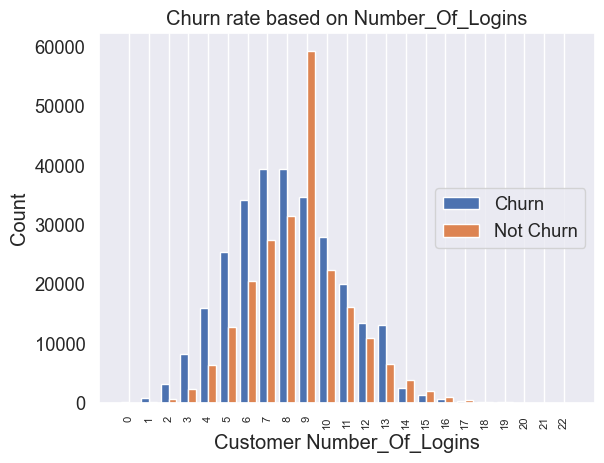

In [62]:
# Are there any noticeable trends in Number_Of_Logins among customers who churned?

filtered = df.groupby(['Number_Of_Logins', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label='Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label='Not Churn')

plt.xticks(X_axis, X, rotation=90, fontsize=8)  # Smaller font size
plt.xlabel("Customer Number_Of_Logins")
plt.ylabel('Count')
plt.title("Churn rate based on Number_Of_Logins")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         505206 non-null  int64  
 1   gender                      505206 non-null  object 
 2   tenure                      505206 non-null  int64  
 3   usage_frequency             505206 non-null  int64  
 4   support_calls               505206 non-null  int64  
 5   payment_delay               505206 non-null  int64  
 6   subscription_type           505206 non-null  object 
 7   contract_length             505206 non-null  object 
 8   total_spend                 505206 non-null  float64
 9   last_interaction            505206 non-null  int64  
 10  churn                       505206 non-null  int64  
 11  Industry                    505206 non-null  object 
 12  Role                        505206 non-null  object 
 13  Market_Segment     

In [73]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())



Column: age
age
18     9493
19     9352
20    10941
21    10825
22    10905
23    10798
24    10717
25    10995
26    10973
27    10787
28    10886
29    10901
30    12231
31    12432
32    12169
33    12247
34    12171
35    12353
36    12436
37    12391
38    12470
39    12310
40    13613
41    13608
42    13873
43    13651
44    13658
45    13546
46    13647
47    13755
48    13632
49    13641
50    14787
51     6803
52     6839
53     6949
54     6894
55     6975
56     6869
57     6762
58     6822
59     6903
60     6832
61     6821
62     6685
63     7033
64     6891
65     6934
Name: count, dtype: int64

Column: gender
gender
Female    224933
Male      280273
Name: count, dtype: int64

Column: tenure
tenure
1     7340
2     7512
3     7393
4     7564
5     7636
6     8643
7     8570
8     8582
9     8446
10    8597
11    8656
12    7550
13    7539
14    7527
15    7579
16    7622
17    7571
18    7674
19    7491
20    7567
21    7693
22    7713
23    7525
24    7753
25    8758


In [64]:
df.isnull().sum()

age                           0
gender                        0
tenure                        0
usage_frequency               0
support_calls                 0
payment_delay                 0
subscription_type             0
contract_length               0
total_spend                   0
last_interaction              0
churn                         0
Industry                      0
Role                          0
Market_Segment                0
Days_Since_Email_Opened       0
Days_Since_CTA_Clicked        0
Days_Since_Website_Visited    0
Days_Since_Event_Attended     0
Days_Since_Last_Login         0
Number_Of_Logins              0
dtype: int64